In [ ]:
# CELL 1: Install all dependencies
!pip install nltk gensim scikit-learn transformers torch
!pip install datasets vaderSentiment pyLDAvis wordcloud
!pip install sentence-transformers spacy networkx
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 126.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# CELL 2: All imports
import nltk, re, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

warnings.filterwarnings('ignore')
nltk.download(['punkt','stopwords','wordnet','averaged_perceptron_tagger',
               'maxent_ne_chunker','words','omw-1.4','punkt_tab'], quiet=True)

RESULTS = {}
print(" Imports done")

 Imports done


In [ ]:
# CELL 3: Load IMDB 50K Movie Reviews dataset
from datasets import load_dataset

print(" Loading IMDB dataset (50K reviews)...")
raw = load_dataset("stanfordnlp/imdb")


train_df = pd.DataFrame(raw['train']).rename(columns={'label':'sentiment'})
test_df  = pd.DataFrame(raw['test']).rename(columns={'label':'sentiment'})


print(f"Train: {len(train_df):,} rows  |  Test: {len(test_df):,} rows")
print(f"Label distribution:\n{train_df['sentiment'].value_counts()}")
train_df.head(3)

 Loading IMDB dataset (50K reviews)...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 25,000 rows  |  Test: 25,000 rows
Label distribution:
sentiment
0    12500
1    12500
Name: count, dtype: int64


,text,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


In [ ]:
# CELL 4: Work with a 5000-sample subset for speed
from sklearn.utils import resample

df_pos = train_df[train_df['sentiment']==1].sample(2500, random_state=42)
df_neg = train_df[train_df['sentiment']==0].sample(2500, random_state=42)
df     = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

test_pos = test_df[test_df['sentiment']==1].sample(500, random_state=42)
test_neg = test_df[test_df['sentiment']==0].sample(500, random_state=42)
test_df2 = pd.concat([test_pos, test_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Working set: {len(df):,} train  |  {len(test_df2):,} test")
print("\nSample review:")
print(df['text'].iloc[0][:300], "...")

Working set: 5,000 train  |  1,000 test

Sample review:
Winchester '73 is a great story, and that's what I like about it. It's not your everyday western--it uses a rifle, which passes hands from various characters--as a mechanism for telling the story about these people. Rock Hudson plays an indian chief, Jimmy Stewart plays a great leading man with hear ...


In [ ]:
# CELL 5: Full preprocessing — Tokenization, Stopword removal, Stemming, Lemmatization
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemma      = WordNetLemmatizer()

def clean_html(text):
    return re.sub(r'<.*?>', '', text).strip()

def preprocess(text, mode='lemma'):
    text   = clean_html(text.lower())
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    if mode == 'stem':
        return ' '.join(stemmer.stem(t) for t in tokens)
    return ' '.join(lemma.lemmatize(t) for t in tokens)

print(" Preprocessing 5000 reviews (lemmatization)...")
t0 = time.time()
df['clean']      = df['text'].apply(preprocess)
test_df2['clean']= test_df2['text'].apply(preprocess)
print(f"Done in {time.time()-t0:.1f}s")


print("\nOriginal :", df['text'].iloc[0][:120])
print("Lemmatized:", df['clean'].iloc[0][:120])
print("Stemmed   :", preprocess(df['text'].iloc[0], mode='stem')[:120])

 Preprocessing 5000 reviews (lemmatization)...
Done in 12.0s

Original : Winchester '73 is a great story, and that's what I like about it. It's not your everyday western--it uses a rifle, which
Lemmatized: winchester great story like everyday western us rifle pass hand various character mechanism telling story people rock hu
Stemmed   : winchest great stori like everyday western use rifl pass hand variou charact mechan tell stori peopl rock hudson play in


BoW   shape: (5000, 10000)
TF-IDF shape: (5000, 10000)


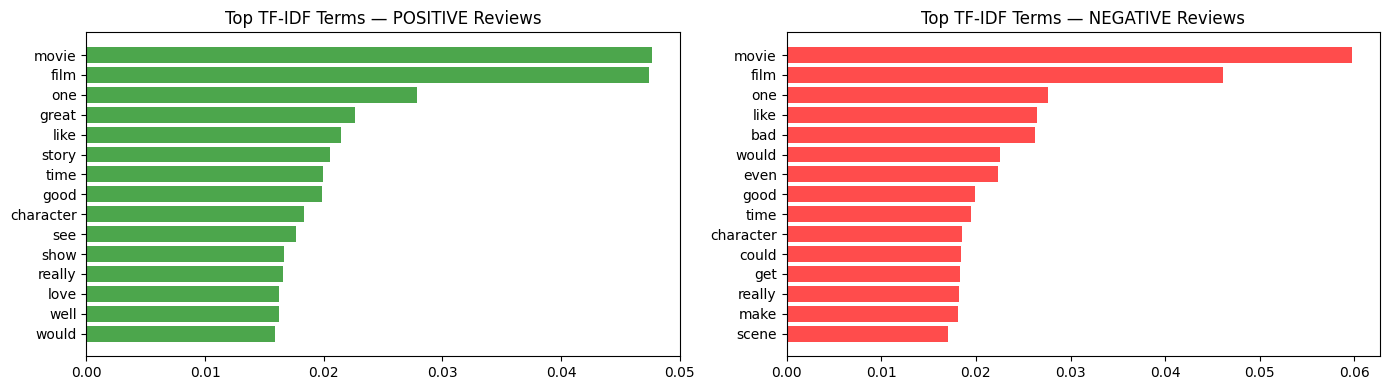

In [ ]:
# CELL 6: Bag of Words and TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vec   = CountVectorizer(max_features=10000)
tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_bow_train   = bow_vec.fit_transform(df['clean'])
X_tfidf_train = tfidf_vec.fit_transform(df['clean'])
X_bow_test    = bow_vec.transform(test_df2['clean'])
X_tfidf_test  = tfidf_vec.transform(test_df2['clean'])
y_train = df['sentiment'].values
y_test  = test_df2['sentiment'].values

print(f"BoW   shape: {X_bow_train.shape}")
print(f"TF-IDF shape: {X_tfidf_train.shape}")

# Top TF-IDF terms by class
terms = tfidf_vec.get_feature_names_out()
pos_idx = df[df['sentiment']==1].index
neg_idx = df[df['sentiment']==0].index
pos_scores = np.asarray(X_tfidf_train[pos_idx].mean(axis=0)).flatten()
neg_scores = np.asarray(X_tfidf_train[neg_idx].mean(axis=0)).flatten()

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,4))
for ax, scores, label, color in [(ax1,pos_scores,'POSITIVE','green'),
                                   (ax2,neg_scores,'NEGATIVE','red')]:
    top = scores.argsort()[-15:][::-1]
    ax.barh([terms[i] for i in top], scores[top], color=color, alpha=0.7)
    ax.set_title(f'Top TF-IDF Terms — {label} Reviews')
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

RESULTS['TF-IDF'] = {'type':'Feature Representation', 'vocab':10000}

In [ ]:
# CELL 7: Bigram Language Model with Laplace Smoothing + Perplexity
from nltk import ngrams as nltk_ngrams

def build_ngram_model(texts, n=2, sample=2000):
    all_tok = []
    for t in texts[:sample]:
        all_tok += ['<s>'] + t.split()[:30] + ['</s>']
    model = defaultdict(Counter)
    for gram in nltk_ngrams(all_tok, n):
        model[gram[:-1]][gram[-1]] += 1
    return model, set(all_tok)

def laplace_prob(model, ctx, word, vocab_size, alpha=1):
    total = sum(model[ctx].values()) + alpha*vocab_size
    return (model[ctx][word] + alpha) / total

def perplexity(model, text, n, vocab):
    toks  = ['<s>'] + text.split()[:20] + ['</s>']
    log_p, cnt = 0, 0
    for gram in nltk_ngrams(toks, n):
        log_p += np.log(laplace_prob(model, gram[:-1], gram[-1], len(vocab)) + 1e-10)
        cnt += 1
    return np.exp(-log_p/cnt) if cnt else float('inf')

bigram_model, vocab_bg = build_ngram_model(df['clean'].tolist())

# Perplexity on pos vs neg
pos_pp = np.mean([perplexity(bigram_model, t, 2, vocab_bg)
                  for t in df[df['sentiment']==1]['clean'].iloc[:100]])
neg_pp = np.mean([perplexity(bigram_model, t, 2, vocab_bg)
                  for t in df[df['sentiment']==0]['clean'].iloc[:100]])
print(f"Avg Bigram Perplexity — Positive: {pos_pp:.1f}  |  Negative: {neg_pp:.1f}")

# Predict next word
sample_ctx = ('movie',)
all_words_bg = list(vocab_bg)
probs = {w: laplace_prob(bigram_model, sample_ctx, w, len(vocab_bg)) for w in all_words_bg}
top5  = sorted(probs, key=probs.get, reverse=True)[:5]
print(f"\nBigram top-5 next words after 'movie': {top5}")
RESULTS['N-gram LM (Bigram)'] = {'type':'Language Model',
                                  'avg_perplexity_pos': round(pos_pp,1),
                                  'avg_perplexity_neg': round(neg_pp,1)}

Avg Bigram Perplexity — Positive: 4434.8  |  Negative: 4390.8

Bigram top-5 next words after 'movie': ['ever', '</s>', 'like', 'really', 'bad']


In [ ]:
# CELL 8: Word2Vec trained on IMDB reviews
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

tokenized_corpus = [t.split() for t in df['clean'].tolist()]

print("Training CBOW...")
cbow = Word2Vec(tokenized_corpus, vector_size=100, window=5,
                min_count=5, sg=0, epochs=10, workers=4)
print("Training Skip-gram...")
skg  = Word2Vec(tokenized_corpus, vector_size=100, window=5,
                min_count=5, sg=1, epochs=10, workers=4)

for name, model in [('CBOW', cbow), ('Skip-gram', skg)]:
    try:
        sim = model.wv.most_similar('film', topn=5)
        print(f"\n{name} — words similar to 'film': {[w for w,_ in sim]}")
        v1 = model.wv['good'].reshape(1,-1)
        v2 = model.wv['bad'].reshape(1,-1)
        print(f"  cos_sim(good, bad): {cos_sim(v1,v2)[0][0]:.4f}  (expect low/negative)")
        v3 = model.wv['excellent'].reshape(1,-1)
        print(f"  cos_sim(good, excellent): {cos_sim(v1,v3)[0][0]:.4f}  (expect high)")
        RESULTS[f'Word2Vec {name}'] = {'type':'Word Embedding',
                                       'cos_sim_good_bad':    round(float(cos_sim(v1,v2)[0][0]),4),
                                       'cos_sim_good_excellent': round(float(cos_sim(v1,v3)[0][0]),4)}
    except KeyError as e:
        print(f"  Word not in vocab: {e}")

Training CBOW...
Training Skip-gram...

CBOW — words similar to 'film': ['movie', 'piece', 'documentary', 'reviewer', 'certainly']
  cos_sim(good, bad): 0.6400  (expect low/negative)
  cos_sim(good, excellent): 0.5361  (expect high)

Skip-gram — words similar to 'film': ['movie', 'deathtrap', 'miniseries', 'pap', 'generous']
  cos_sim(good, bad): 0.6198  (expect low/negative)
  cos_sim(good, excellent): 0.4720  (expect high)


In [ ]:
# CELL 9: VADER on IMDB test set (lexicon-based, no training)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report

vader = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = vader.polarity_scores(text)['compound']
    return 1 if score >= 0.05 else 0

# Evaluate on 1000 test reviews (raw text, not cleaned — VADER needs punctuation)
sample_test = test_df2.sample(1000, random_state=42)
vader_preds = sample_test['text'].apply(vader_predict).values
vader_true  = sample_test['sentiment'].values
vader_acc   = accuracy_score(vader_true, vader_preds)

print(f"VADER Accuracy on IMDB test (1000 samples): {vader_acc:.4f}")
print(classification_report(vader_true, vader_preds,
                             target_names=['Negative','Positive']))
RESULTS['VADER (Lexicon)'] = {'type':'Sentiment Analysis',
                               'accuracy': round(vader_acc,4), 'f1': None,
                               'method':'Lexicon-based (no training)'}

VADER Accuracy on IMDB test (1000 samples): 0.7180
              precision    recall  f1-score   support

    Negative       0.79      0.59      0.68       500
    Positive       0.67      0.85      0.75       500

    accuracy                           0.72      1000
   macro avg       0.73      0.72      0.71      1000
weighted avg       0.73      0.72      0.71      1000



In [ ]:
# CELL 10: Multinomial Naive Bayes on IMDB TF-IDF features
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

nb = MultinomialNB(alpha=0.5)
nb.fit(X_tfidf_train, y_train)
preds_nb = nb.predict(X_tfidf_test)

acc_nb = accuracy_score(y_test, preds_nb)
f1_nb  = f1_score(y_test, preds_nb)
print(f"Naive Bayes  →  Accuracy: {acc_nb:.4f}  |  F1: {f1_nb:.4f}")
print(classification_report(y_test, preds_nb, target_names=['Negative','Positive']))
RESULTS['Naive Bayes'] = {'type':'ML Classifier', 'accuracy': round(acc_nb,4),
                           'f1': round(f1_nb,4)}

Naive Bayes  →  Accuracy: 0.8440  |  F1: 0.8418
              precision    recall  f1-score   support

    Negative       0.83      0.86      0.85       500
    Positive       0.85      0.83      0.84       500

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



In [ ]:
# CELL 11: Logistic Regression on IMDB TF-IDF
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs')
lr.fit(X_tfidf_train, y_train)
preds_lr = lr.predict(X_tfidf_test)

acc_lr = accuracy_score(y_test, preds_lr)
f1_lr  = f1_score(y_test, preds_lr)
print(f"Logistic Regression  →  Accuracy: {acc_lr:.4f}  |  F1: {f1_lr:.4f}")
print(classification_report(y_test, preds_lr, target_names=['Negative','Positive']))
RESULTS['Logistic Regression'] = {'type':'ML Classifier', 'accuracy': round(acc_lr,4),
                                   'f1': round(f1_lr,4)}

Logistic Regression  →  Accuracy: 0.8580  |  F1: 0.8571
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86       500
    Positive       0.86      0.85      0.86       500

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



In [ ]:
# CELL 12: Linear SVM on IMDB TF-IDF
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = LinearSVC(C=1.0, max_iter=2000)
svm.fit(X_tfidf_train, y_train)
preds_svm = svm.predict(X_tfidf_test)

acc_svm = accuracy_score(y_test, preds_svm)
f1_svm  = f1_score(y_test, preds_svm)
print(f"SVM (LinearSVC)  →  Accuracy: {acc_svm:.4f}  |  F1: {f1_svm:.4f}")
print(classification_report(y_test, preds_svm, target_names=['Negative','Positive']))
RESULTS['SVM (LinearSVC)'] = {'type':'ML Classifier', 'accuracy': round(acc_svm,4),
                               'f1': round(f1_svm,4)}

SVM (LinearSVC)  →  Accuracy: 0.8410  |  F1: 0.8396
              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84       500
    Positive       0.85      0.83      0.84       500

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



In [ ]:
# CELL 13: LDA on IMDB — discover hidden review themes
from sklearn.decomposition import LatentDirichletAllocation

# Use BoW subset for LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42,
                                  max_iter=20, learning_method='online')
lda.fit(X_bow_train)

bow_terms = bow_vec.get_feature_names_out()
print(" LDA Topics discovered from IMDB reviews:")
for i, topic in enumerate(lda.components_):
    top_words = [bow_terms[j] for j in topic.argsort()[-10:][::-1]]
    print(f"  Topic {i+1}: {', '.join(top_words)}")

RESULTS['LDA (Topic Model)'] = {'type':'Unsupervised / Topic Model', 'n_topics':5}

 LDA Topics discovered from IMDB reviews:
  Topic 1: film, one, man, woman, two, take, zombie, little, life, find
  Topic 2: john, get, man, family, father, go, brother, star, new, match
  Topic 3: war, film, world, political, human, documentary, effect, man, shooting, earth
  Topic 4: film, one, great, story, performance, character, best, also, role, actor
  Topic 5: movie, film, one, like, would, good, time, even, really, get


In [ ]:
# CELL 14: NMF Topic Modeling on IMDB
from sklearn.decomposition import NMF

nmf = NMF(n_components=5, random_state=42, max_iter=200)
nmf.fit(X_tfidf_train)

tfidf_terms = tfidf_vec.get_feature_names_out()
print(" NMF Topics discovered from IMDB reviews:")
for i, topic in enumerate(nmf.components_):
    top_words = [tfidf_terms[j] for j in topic.argsort()[-10:][::-1]]
    print(f"  Topic {i+1}: {', '.join(top_words)}")

RESULTS['NMF (Topic Model)'] = {'type':'Unsupervised / Topic Model', 'n_topics':5}

📌 NMF Topics discovered from IMDB reviews:
  Topic 1: story, one, character, life, man, also, get, two, love, woman
  Topic 2: movie, like, seen, good, see, watch, great, would, really, think
  Topic 3: show, episode, series, season, tv, like, would, watch, really, year
  Topic 4: bad, even, like, acting, guy, worst, get, one, thing, could
  Topic 5: film, see, one, seen, made, great, would, director, time, many


In [ ]:
# CELL 15: POS Tagging and NER using spaCy on IMDB samples
import spacy
nlp_spacy = spacy.load('en_core_web_sm')

sample_reviews = test_df2['text'].iloc[:5].tolist()
all_entities = Counter()

print(" NER on sample IMDB reviews:\n")
for i, rev in enumerate(sample_reviews):
    doc = nlp_spacy(rev[:300])
    ents = [(e.text, e.label_) for e in doc.ents]
    all_entities.update([e[1] for e in ents])
    print(f"Review {i+1}: {ents[:5]}")

print("\n Entity type distribution across samples:")
print(all_entities.most_common(10))
RESULTS['NER (spaCy)'] = {'type':'Sequence Labeling',
                           'top_entity_type': all_entities.most_common(1)[0][0]
                           if all_entities else 'N/A'}

🔍 NER on sample IMDB reviews:

Review 1: [('an Adam Sandler "Happy Madison', 'PERSON')]
Review 2: []
Review 3: [('first', 'ORDINAL'), ('seven', 'CARDINAL'), ('four', 'CARDINAL')]
Review 4: [('Gregory Dark', 'FAC'), ('Glen Jacobs', 'PERSON'), ('Kane', 'PERSON'), ('Jacob Goodknight', 'PERSON')]
Review 5: [('one', 'CARDINAL'), ('Vietnam', 'GPE'), ('The Ten Thousand Day War', 'EVENT'), ('DVR', 'ORG'), ('Florida', 'GPE')]

📊 Entity type distribution across samples:
[('PERSON', 4), ('CARDINAL', 3), ('GPE', 3), ('ORDINAL', 1), ('FAC', 1), ('EVENT', 1), ('ORG', 1)]
